<div style="background:linear-gradient(135deg,#1e1b4b 0%,#4338ca 55%,#6366f1 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#c7d2fe;font-weight:700;text-transform:uppercase">Chapter 112 · Model Pitfalls</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">Model Pitfalls</div>
  <div style="font-size:15px;color:#e0e7ff;max-width:740px;line-height:1.6">The four traps that catch everyone: overfitting vs underfitting, the bias-variance trade-off, imbalanced data with class_weight and SMOTE, and the cross-validation strategies (stratified, time-series, group) that keep estimates honest, all library-first and visual.</div>
  <div style="margin-top:16px;font-size:13px;color:#c7d2fe">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

# Model Pitfalls: overfitting, bias-variance, imbalance, and CV
A model can look great and still be broken. This notebook works the four traps that catch everyone: **overfitting vs underfitting**, the **bias-variance trade-off** behind them, **imbalanced data** (and how `class_weight` and **SMOTE** rescue the minority class), and the **cross-validation strategies** that keep your estimates honest. Library-first with `scikit-learn` and `imbalanced-learn`.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns   # seaborn = high-level statistical plots (heatmaps, pairplots, count/bar plots)
from matplotlib.colors import ListedColormap
EM="#4338ca"; DEEP="#3730a3"; LIGHT="#c7d2fe"; INK="#1a2138"; GRID="#e6e9f2"; RED="#ef4444"; AMBER="#d97706"; GREEN="#059669"; BLUE="#2563eb"; PUR="#9333ea"; GREY="#94a3b8"; SLATE="#475569"; ORG="#4338ca"; CYAN="#0891b2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
sns.set_style("whitegrid")
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"

In [2]:
import warnings; warnings.filterwarnings('ignore')
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import (train_test_split, validation_curve, learning_curve,
    KFold, StratifiedKFold, TimeSeriesSplit, cross_val_score)
from sklearn.metrics import mean_squared_error, recall_score, precision_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline as imb_make_pipeline
pd.set_option('display.max_columns', 30)

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 1 &#183; OVERFITTING vs UNDERFITTING</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Too simple, too complex, and just right</div>
<div style="color:#4a5578;margin-top:6px">The same data fit three ways.</div>
</div>

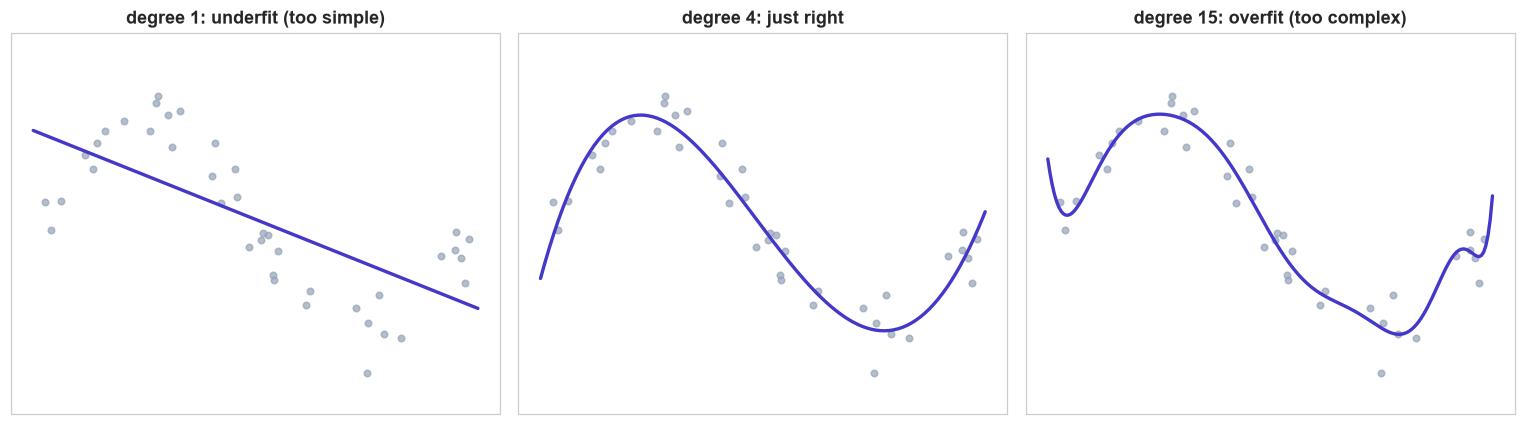

In [3]:
rng = np.random.default_rng(1)
xt = np.sort(rng.uniform(0, 1, 40)); yt = np.sin(2*np.pi*xt) + rng.normal(0, 0.25, 40)   # true curve + noise
xx = np.linspace(0, 1, 200)
fig, ax = plt.subplots(1, 3, figsize=(14,4))
for a,(deg,lab) in zip(ax, [(1,'underfit (too simple)'),(4,'just right'),(15,'overfit (too complex)')]):
    m = make_pipeline(PolynomialFeatures(deg), LinearRegression()).fit(xt.reshape(-1,1), yt)
    a.scatter(xt, yt, s=18, color=GREY, alpha=0.7); a.plot(xx, m.predict(xx.reshape(-1,1)), color=EM, lw=2.2)
    a.set(title=f'degree {deg}: {lab}', ylim=(-1.8,1.8), xticks=[], yticks=[])
plt.tight_layout(); plt.show()

**The two ways to fail.** A model that is **too simple** (a straight line) cannot capture the real pattern, it **underfits** (high bias). A model that is **too complex** (a degree-15 polynomial) bends to chase every noisy point, it **overfits** (high variance) and will generalize terribly. The **just right** model in the middle captures the true curve without chasing the noise. The whole art of modeling is finding that middle.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 2 &#183; THE BIAS-VARIANCE TRADE-OFF</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Why there is a sweet spot</div>
<div style="color:#4a5578;margin-top:6px">Train error always falls; test error is U-shaped.</div>
</div>

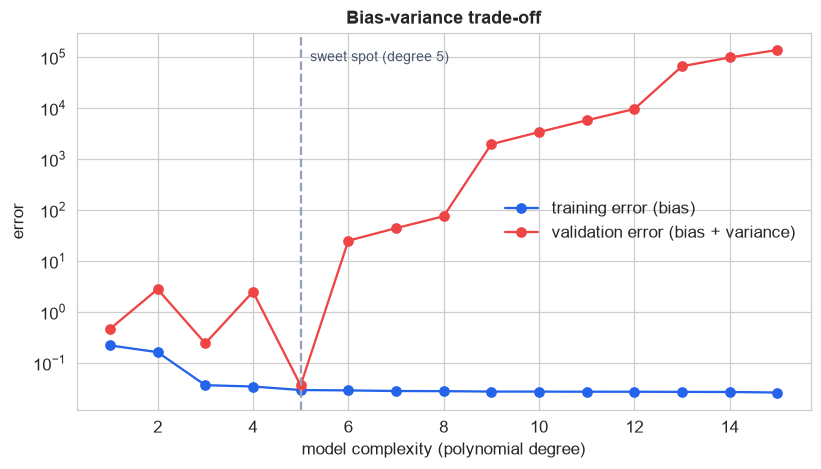

In [4]:
degrees = range(1, 16)
tr, va = validation_curve(make_pipeline(PolynomialFeatures(1), LinearRegression()), xt.reshape(-1,1), yt,
    param_name='polynomialfeatures__degree', param_range=list(degrees), cv=5, scoring='neg_mean_squared_error')
tr_err, va_err = -tr.mean(axis=1), -va.mean(axis=1)
best = list(degrees)[int(np.argmin(va_err))]
fig, ax = plt.subplots(figsize=(7.6,4.4))
ax.plot(degrees, tr_err, 'o-', color=BLUE, label='training error (bias)')
ax.plot(degrees, va_err, 'o-', color=RED, label='validation error (bias + variance)')
ax.axvline(best, color=GREY, ls='--'); ax.text(best+0.2, max(va_err)*0.6, f'sweet spot (degree {best})', fontsize=9, color=SLATE)
ax.set(title='Bias-variance trade-off', xlabel='model complexity (polynomial degree)', ylabel='error', yscale='log'); ax.legend()
plt.tight_layout(); plt.show()

**The core trade-off.** As complexity grows, **training error keeps falling** (a flexible model fits the training points ever better), but **validation error is U-shaped**: it drops as the model stops underfitting, bottoms out, then rises as the model starts overfitting. On the left the error is dominated by **bias** (too rigid); on the right by **variance** (too sensitive to the particular sample). The best model sits at the bottom of the U, and cross-validation is how you find it.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 3 &#183; DOES MORE DATA HELP?</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Learning curves diagnose the problem</div>
<div style="color:#4a5578;margin-top:6px">More data cures variance, not bias.</div>
</div>

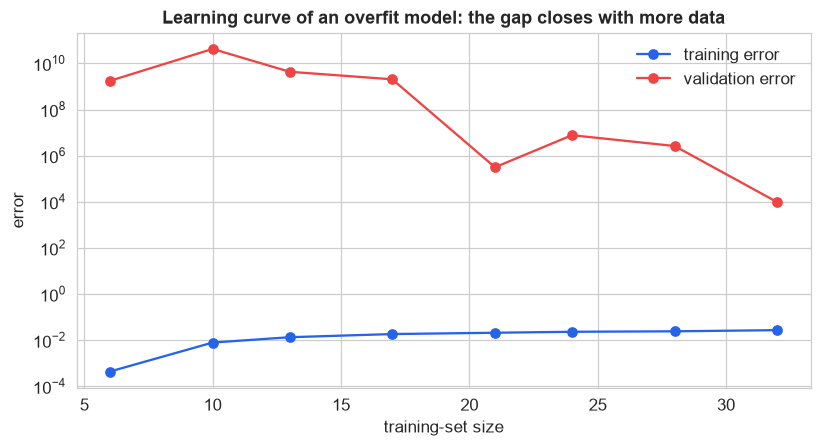

In [5]:
sizes, tr_s, va_s = learning_curve(make_pipeline(PolynomialFeatures(12), LinearRegression()),
    xt.reshape(-1,1), yt, train_sizes=np.linspace(0.2, 1.0, 8), cv=5, scoring='neg_mean_squared_error')
fig, ax = plt.subplots(figsize=(7.6,4.2))
ax.plot(sizes, -tr_s.mean(axis=1), 'o-', color=BLUE, label='training error')
ax.plot(sizes, -va_s.mean(axis=1), 'o-', color=RED, label='validation error')
ax.set(title='Learning curve of an overfit model: the gap closes with more data', xlabel='training-set size', ylabel='error', yscale='log'); ax.legend()
plt.tight_layout(); plt.show()

**Reading a learning curve.** Plot training and validation error against the amount of data. A wide **gap** between them (low training error, high validation error) is the signature of **overfitting / high variance**, and it <em>shrinks as you add data</em>, so more data helps. But if both curves are high and close together, the model is **underfitting / high bias**, and more data will not help; you need a more flexible model or better features instead. The learning curve tells you which problem you have, and therefore what to do.

<div style="background:#eef6ff;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#1d4ed8;letter-spacing:1px">DEMO 4 &#183; IMBALANCED DATA &amp; SMOTE</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">When one class is rare</div>
<div style="color:#4a5578;margin-top:6px">Rebalancing rescues minority-class recall.</div>
</div>

defect rate = 7.4%  (imbalanced)
plain                    recall 0.074  precision 0.500
class_weight='balanced'  recall 0.815  precision 0.191
SMOTE oversampling       recall 0.852  precision 0.209


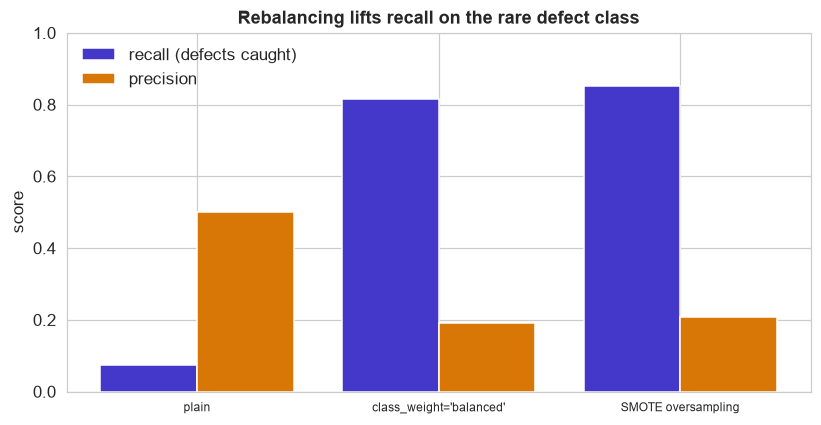

In [6]:
try: df = pd.read_excel('../../data/model-pitfalls--defects.xlsx', sheet_name='Data')
except FileNotFoundError: df = pd.read_excel(BASE + 'model-pitfalls--defects.xlsx', sheet_name='Data')
feat = ['temperature','pressure','line_speed','machine_age_mo','material_grade']
X, y = df[feat], df['defective']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
print(f'defect rate = {y.mean():.1%}  (imbalanced)')
models = {'plain': make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
          "class_weight='balanced'": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced')),
          'SMOTE oversampling': imb_make_pipeline(StandardScaler(), SMOTE(random_state=0), LogisticRegression(max_iter=1000))}
res = {}
for name, m in models.items():
    m.fit(X_tr, y_tr); p = m.predict(X_te)
    res[name] = (recall_score(y_te, p), precision_score(y_te, p))
    print(f'{name:24s} recall {res[name][0]:.3f}  precision {res[name][1]:.3f}')
fig, ax = plt.subplots(figsize=(7.6,4))
names=list(res); rec=[res[n][0] for n in names]; prec=[res[n][1] for n in names]; xp=np.arange(len(names))
ax.bar(xp-0.2, rec, 0.4, color=EM, label='recall (defects caught)'); ax.bar(xp+0.2, prec, 0.4, color=AMBER, label='precision')
ax.set_xticks(xp); ax.set_xticklabels(names, fontsize=8); ax.set(title='Rebalancing lifts recall on the rare defect class', ylabel='score', ylim=(0,1)); ax.legend()
plt.tight_layout(); plt.show()

**The imbalance trap and its fixes.** With only ~7% defects, the **plain** model barely flags any, recall about **0.07**, it optimizes overall accuracy by mostly ignoring the rare class. Two fixes rescue it. **`class_weight='balanced'`** tells the model to penalize minority mistakes more heavily, lifting recall to about **0.82**. **SMOTE** (Synthetic Minority Over-sampling Technique) invents plausible new minority examples between existing ones to balance the training set, reaching about **0.85**. Both trade some precision (more false alarms) for far better recall, usually the right call when a missed defect is costly. Note SMOTE lives **inside the pipeline** so it only ever resamples the training fold, never the validation data.

<div style="background:#eef2ff;border-left:5px solid #4338ca;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#3730a3;letter-spacing:1px">DEMO 5 &#183; CROSS-VALIDATION STRATEGIES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Match the split to the data</div>
<div style="color:#4a5578;margin-top:6px">Plain k-fold is not always right.</div>
</div>

In [7]:
print('per-fold defect rate (should stay ~7% to be representative):')
print('  plain KFold      :', [round(float(y_tr.iloc[te].mean()),3) for _,te in KFold(5, shuffle=True, random_state=1).split(X_tr)])
print('  StratifiedKFold  :', [round(float(y_tr.iloc[te].mean()),3) for _,te in StratifiedKFold(5, shuffle=True, random_state=1).split(X_tr, y_tr)])
print('\nTimeSeriesSplit (train always precedes validation, no peeking into the future):')
for i,(tr,te) in enumerate(TimeSeriesSplit(4).split(X_tr)): print(f'  fold {i+1}: train rows 0..{tr[-1]}, validate {te[0]}..{te[-1]}')

per-fold defect rate (should stay ~7% to be representative):
  plain KFold      : [0.042, 0.095, 0.077, 0.042, 0.113]
  StratifiedKFold  : [0.077, 0.077, 0.071, 0.071, 0.071]

TimeSeriesSplit (train always precedes validation, no peeking into the future):
  fold 1: train rows 0..167, validate 168..335
  fold 2: train rows 0..335, validate 336..503
  fold 3: train rows 0..503, validate 504..671
  fold 4: train rows 0..671, validate 672..839


**Pick the right splitter.** Plain **`KFold`** shuffles rows into folds, and on imbalanced data a fold can end up with too few (or too many) defects, giving a noisy estimate. **`StratifiedKFold`** keeps each fold's class ratio matching the whole (about 7% here), the default for classification. **`TimeSeriesSplit`** always trains on the past and validates on the future, essential for time-ordered data where a random shuffle would let the model peek ahead (a leak). **`GroupKFold`** keeps all rows from one group (a patient, a customer) together so the model is tested on unseen groups. The rule: the split must respect the structure of your data.

## The four pitfalls, in one view

- **Underfitting (high bias)**: too simple; both training and validation error high. Fix with a more flexible model or better features.
- **Overfitting (high variance)**: too complex; low training error, high validation error, a wide gap that more data can close.
- **Imbalanced data**: a rare class gets ignored; use `class_weight='balanced'` or **SMOTE**, and judge by recall / precision, not accuracy.
- **The wrong CV split** leaks or misleads; use **stratified** for classification, **time-series** for temporal data, **group** for clustered data.

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>